perbaikan model

membandingkan beberapa algoritma klasifikasi untuk memilih model terbaik

d:\desease-prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


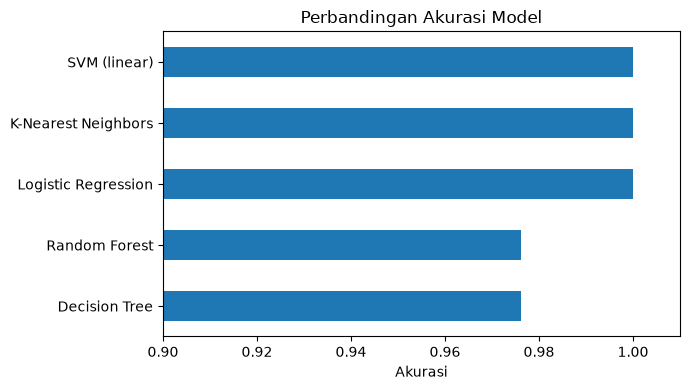

Logistic Regression    1.00000
K-Nearest Neighbors    1.00000
SVM (linear)           1.00000
Decision Tree          0.97619
Random Forest          0.97619
dtype: float64

In [1]:
import sys
sys.path.append("../src")

from preprocessing import load_dataset
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

X_train, y_train, X_test, y_test, feature_cols = load_dataset(
    train_path="../data/Training.csv", test_path="../data/Testing.csv"
)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "SVM (linear)": SVC(kernel="linear", probability=True),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results[name] = accuracy_score(y_test, pred)

pd.Series(results).sort_values().plot(kind="barh", figsize=(7, 4))
plt.title("Perbandingan Akurasi Model")
plt.xlabel("Akurasi")
plt.xlim(0.9, 1.01)
plt.tight_layout()
plt.show()

pd.Series(results).sort_values(ascending=False)

## Hasil & Analisis

| Model | Akurasi |
|---|---|
| Logistic Regression | 100.00% |
| K-Nearest Neighbors | 100.00% |
| SVM (linear) | 100.00% |
| Decision Tree | 97.62% |
| Random Forest | 97.62% |

**Temuan menarik:** model yang lebih sederhana (Logistic Regression, KNN, SVM)
justru dapat akurasi **sempurna**, sementara Decision Tree dan Random Forest
"tersandung" di 1 kasus (Fungal infection vs Impetigo — dua penyakit kulit
dengan gejala tumpang tindih). Ini masuk akal: karena datanya adalah lookup
table gejala→penyakit, model berbasis jarak/linear cenderung lebih "pas" untuk
mencocokkan kombinasi persis, sementara pohon keputusan kadang membuat split
acak di titik yang ambigu.

**Kenapa saya tetap pilih Random Forest sebagai model final** (lihat notebook
03): meski bukan yang paling akurat di sini, Random Forest punya
`feature_importances_` bawaan yang membuatnya lebih mudah dijelaskan — gejala
mana yang paling berpengaruh ke prediksi. Untuk proyek yang berkaitan dengan
kesehatan, transparansi seperti ini penting, bukan cuma soal akurasi tertinggi.